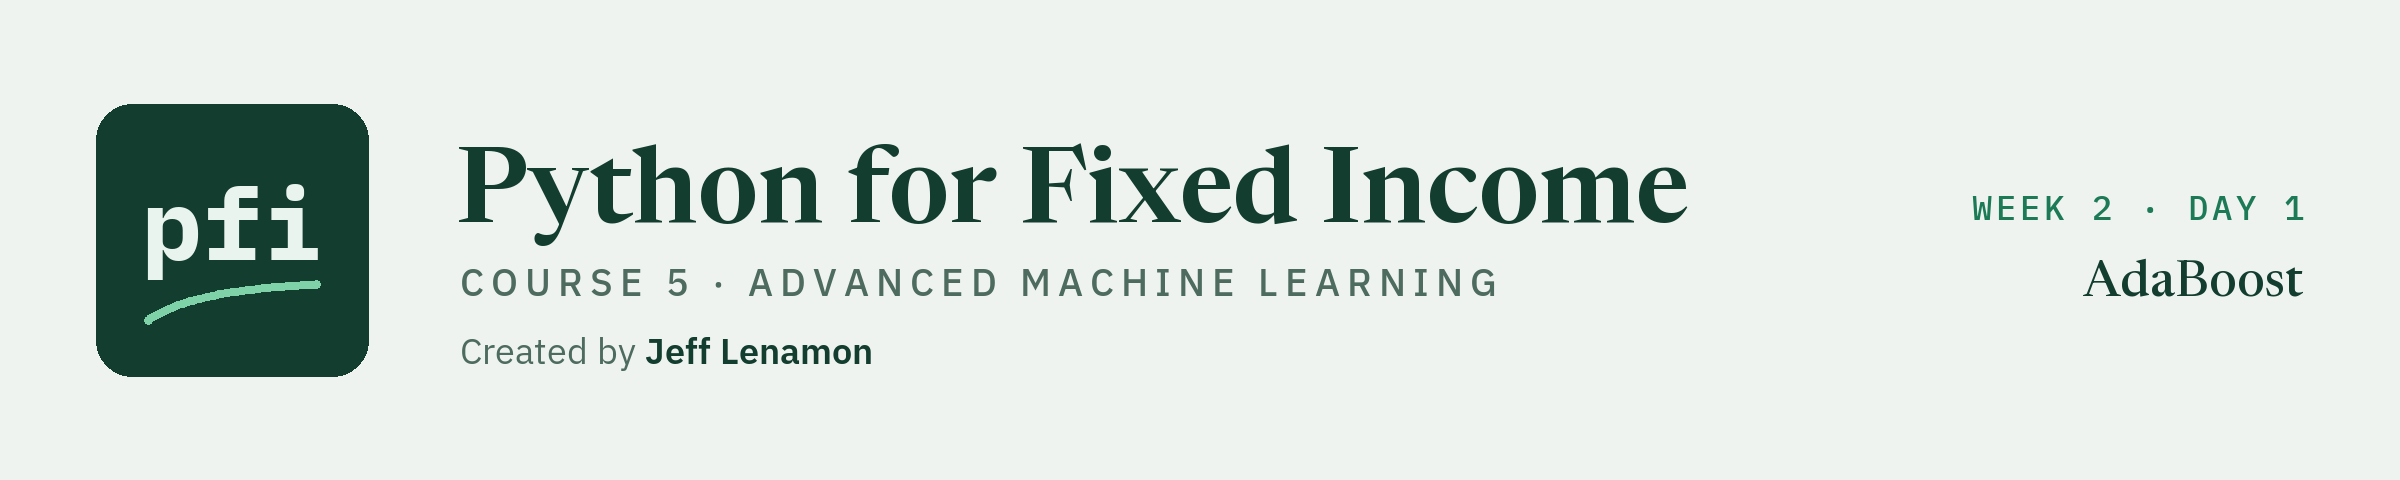

# AdaBoost

Week 2, Day 1. Week 1 averaged trees fitted side by side. Boosting fits them one after another, each on the rows the last one got wrong. Today: AdaBoost, built by hand one round at a time, matched to scikit-learn, and read for what its output is and is not.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week2/day1/06_adaboost.ipynb)

Week 1 grew many trees independently, each on its own bootstrap sample, and averaged them: averaging cancels the noise of trees that disagree. Week 2 turns the idea around. **Boosting** grows trees one after another, and each new tree is fitted to the rows the trees before it got wrong. The members are not independent at all: each one exists to fix its predecessors.

AdaBoost is the oldest form of boosting still in everyday use, and it is small enough to build by hand. Each member is a **stump**, a tree with one question. After each round, the rows the stump got wrong are given more weight, so the next stump has to care about them. Every stump gets a vote, and a better stump gets a bigger vote.

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` holds 30,000 credit card accounts in Taiwan in 2005, with payment records from April to September and an outcome for the following month. Consumer credit there differs from US credit, and nothing here describes any other market.
* **People's attributes are never features.** `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` are in no model and no output is grouped by them. Every model today uses the other 19 columns, Course 4's.
* **Course 4's split, rebuilt, with the test rows closed.** Day 1's test-row rule holds: Course 4's 6,000 test rows are never scored, the 6,000 validation rows report and choose nothing, and every setting is compared inside the 18,000 training rows.
* **A model's output is described, never acted on.** AdaBoost's output is the model's score (section 6.7 shows why it is not a frequency), or a flag at a threshold. No output of either kind is a credit decision for any person.

Today you will:

1. Contrast bagging, trees side by side, with boosting, trees one after another.
2. Fit a stump and read its one question.
3. Run AdaBoost's first round by hand: the weighted error, the stump's weight (`samme_alpha`), and the new row weights (`reweight`).
4. Run three rounds by hand and match scikit-learn's `AdaBoostClassifier` to 1e-12.
5. Fit 200 stumps and score them on the validation rows.
6. Compare learning rates and numbers of rounds by cross-validation inside the training rows.
7. Read AdaBoost's output as a weighted vote turned into a score, with one calibration chart.
8. Describe the rows that carry the most weight after 50 rounds.

Q. Set up today's work folder: the thread settings, the seed, the modules as day 5 left them, and the data files.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_06_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv", "benchmark.csv", "ratings.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_06_ubg4tldf, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv, benchmark.csv, ratings.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)


from types import SimpleNamespace

from sklearn.ensemble import RandomForestClassifier


class StandInTree:
    """A stand-in for a fitted tree: its class-1 output is the first column plus a constant."""

    def __init__(self, shift: float):
        self.shift = shift

    def predict_proba(self, values: np.ndarray) -> np.ndarray:
        p = values[:, 0] / 10 + self.shift
        return np.column_stack([1 - p, p])


def test_tree_correlation_hand():
    X = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0], "b": [0.0, 0.0, 1.0, 1.0]})
    # two outputs that differ by a constant are perfectly correlated
    forest = SimpleNamespace(estimators_=[StandInTree(0.1), StandInTree(0.3)])
    assert ensemblekit.tree_correlation(forest, X) == pytest.approx(1.0, abs=1e-12)


def test_tree_correlation_forest_below_bagging():
    X, y = card_small()
    _, X_valid, _, _ = card_rows()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED,
                                n_jobs=1).fit(X, y)
    forest = RandomForestClassifier(n_estimators=10, random_state=SEED, n_jobs=1).fit(X, y)
    assert forest.estimators_[0].max_features == "sqrt"
    assert ensemblekit.tree_correlation(forest, X_valid) < ensemblekit.tree_correlation(bagging, X_valid)


def test_tree_correlation_rejects_one_tree():
    X, y = card_small(500)
    forest = RandomForestClassifier(n_estimators=1, random_state=SEED, n_jobs=1).fit(X, y)
    with pytest.raises(ValueError, match="at least two trees"):
        ensemblekit.tree_correlation(forest, X)


from sklearn.inspection import permutation_importance


@cache
def forest_with_noise() -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    """A 50-tree forest with 20-row leaves on 3,000 training rows plus a column of random numbers, and 2,000
    validation rows with their own random column."""
    X, y = card_small()
    _, X_valid, _, y_valid = card_rows()
    rng = np.random.default_rng(SEED)
    X = X.assign(noise=rng.normal(size=len(X)))
    X_valid = X_valid.iloc[:2_000].assign(noise=rng.normal(size=2_000))
    forest = RandomForestClassifier(n_estimators=50, min_samples_leaf=20, random_state=SEED, n_jobs=1).fit(X, y)
    return forest, X_valid, y_valid.iloc[:2_000]


def test_importance_table_columns_and_ranks():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    assert list(table.columns) == ["impurity", "permutation", "permutation_sd", "impurity_rank", "permutation_rank"]
    assert set(table.index) == set(X_valid.columns)
    assert table["impurity"].sum() == pytest.approx(1.0, abs=1e-12)
    assert table["permutation"].is_monotonic_decreasing
    assert table["permutation_rank"].iloc[0] == 1
    assert table.loc[table["impurity"].idxmax(), "impurity_rank"] == 1


def test_importance_table_matches_permutation_importance():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid, n_repeats=3)
    direct = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=3, random_state=SEED,
                                    n_jobs=1)
    expected = pd.Series(direct.importances_mean, index=X_valid.columns)
    assert table["permutation"].to_numpy() == pytest.approx(expected[table.index].to_numpy(), abs=1e-12)


def test_importance_table_noise_near_zero():
    forest, X_valid, y_valid = forest_with_noise()
    table = ensemblekit.importance_table(forest, X_valid, y_valid)
    # on unseen rows, shuffling a column of random numbers costs (almost) nothing
    assert abs(table.loc["noise", "permutation"]) < 0.01
    assert table.loc["PAY_0", "permutation"] > 10 * abs(table.loc["noise", "permutation"])


def test_importance_table_rejects_model_without_importances():
    X, y = card_small(500)
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X, y)
    with pytest.raises(ValueError, match="feature_importances_"):
        ensemblekit.importance_table(model, X, y)


from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted


@cache
def bench_rows() -> pd.DataFrame:
    """Course 4's 615 training bonds."""
    return ensemblekit.course4_bench_rows(pd.read_csv(HERE / "benchmark.csv"), pd.read_csv(HERE / "ratings.csv"))


def test_course4_bench_rows_counts_and_closed():
    train = bench_rows()
    assert len(train) == 615
    assert {"score", "log_oas", "years", "amount_bn"} <= set(train.columns)
    assert train["log_oas"].to_numpy() == pytest.approx(np.log(train["oas"]).to_numpy(), abs=1e-12)
    # Course 4's test bonds, recomputed with Course 4's call on the file
    bench = pd.read_csv(HERE / "benchmark.csv")
    _, bench_test = train_test_split(bench, test_size=0.25, random_state=SEED)
    assert len(bench_test) == 206
    assert not set(bench_test["cusip"]) & set(train["cusip"])
    with pytest.raises(ValueError):
        ensemblekit.course4_bench_rows(bench.iloc[:800], pd.read_csv(HERE / "ratings.csv"))


def test_oof_threshold_meets_recall():
    X, y = card_small()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    threshold, proba = ensemblekit.oof_threshold(model, X, y, target_recall=0.70)
    assert proba.shape == (len(X),)
    flagged = proba >= threshold
    assert flagged[y.to_numpy() == 1].mean() >= 0.70
    # the next higher distinct probability would miss the target
    higher = np.unique(proba[proba > threshold])
    if higher.size:
        assert (proba >= higher[0])[y.to_numpy() == 1].mean() < 0.70


def test_oof_threshold_does_not_fit_callers_model():
    X, y = card_small(1_000)
    model = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    ensemblekit.oof_threshold(model, X, y)
    with pytest.raises(NotFittedError):
        check_is_fitted(model)

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag', 'bagged_proba', 'oob_auc', 'tree_correlation', 'importance_table', 'course4_bench_rows', 'oof_threshold']


* The work folder starts fresh each day. `ensemblekit.py` and `test_ensemblekit.py` are written as day 5 left them; the benchmark files are copied because day 5's tests read them.

Q. Load the card accounts and take Course 4's training and validation rows.

In [6]:
# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")

# Course 4's split, rebuilt: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
# the four columns that describe people are never features: stop if one slips in
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"
n_rows = len(X_train)

print(f"training rows: {n_rows:,}, default rate {y_train.mean():.2%}")
print(f"validation rows: {len(X_valid):,}, default rate {y_valid.mean():.2%}")

training rows: 18,000, default rate 22.12%
validation rows: 6,000, default rate 22.12%


* Course 4's 18,000 training and 6,000 validation rows, both with a default rate of 22.12 percent.

## 6.1 Side by Side, or One After Another

Both families combine many trees. They differ in how each tree is made and how the trees are combined.

| | Bagging and forests (week 1) | Boosting (week 2) |
| --- | --- | --- |
| How each tree sees the rows | its own bootstrap sample, drawn at random | every row, with weights set by the trees before it |
| Order | independent: the trees could be fitted in any order | one after another: tree k needs trees 1 to k - 1 |
| The trees | deep, unstable, and different from each other | small and weak: today, one question each |
| How they combine | a plain average | a weighted vote: better trees count for more |
| What it fixes | the noise of one deep tree | the bias of one small tree |

A stump on its own is far too simple to describe the card file. AdaBoost's bet is that many stumps, each aimed at what the others missed, add up to a model that is not simple at all.

## 6.2 A Stump

Q. Fit a stump, a tree with one question, on the training rows. What does it ask, and how well does it rank the validation accounts?

In [7]:
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

# a stump: a decision tree allowed one question (depth 1)
stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X_train, y_train)
feature, threshold = X_train.columns[stump.tree_.feature[0]], stump.tree_.threshold[0]
yes_side = (X_train[feature] <= threshold).to_numpy()

print(f"the stump asks: {feature} <= {threshold}")
print(f"yes side: {yes_side.sum():,} training rows, default rate {y_train[yes_side].mean():.2%}")
print(f"no side: {(~yes_side).sum():,} training rows, default rate {y_train[~yes_side].mean():.2%}")
print(f"the stump flags the no side: {(stump.predict(X_train) == (~yes_side)).all()}")
print(f"stump: validation ROC AUC {roc_auc_score(y_valid, stump.predict_proba(X_valid)[:, 1]):.4f}")

the stump asks: PAY_0 <= 1.5
yes side: 16,115 training rows, default rate 16.51%
no side: 1,885 training rows, default rate 70.13%
the stump flags the no side: True
stump: validation ROC AUC 0.6361


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows and scored on Course 4's 6,000 validation rows, or by five-fold cross-validation inside the training rows where settings are compared; Course 4's 6,000 test rows are never scored in this course.

* The stump asks `PAY_0 <= 1.5`, the first question every tree of week 1 asked: whether the account's most recent repayment status shows a delay of two months or more. On the yes side, 16,115 rows default at 16.5 percent; on the no side, 1,885 rows default at 70.1 percent. Its output is the default rate of its leaf, so it takes two values, and its flag at 0.5 is "on the no side".
* One question ranks the validation accounts at 0.6361, below Course 4's logistic regression (0.7190, recomputed on day 1). A stump is a weak model by design. AdaBoost uses hundreds of them.

## 6.3 Round One by Hand

AdaBoost keeps one weight per training row. It starts with every row at 1/n and repeats four steps:

1. **Fit a stump on the weighted rows.** A row with twice the weight counts twice when the stump chooses its question.
2. **Measure its weighted error** e: the share of the total weight on the rows it gets wrong.
3. **Give the stump a weight**, its say in the final vote: ln((1 - e) / e). A stump right on 80 percent of the weight gets ln(4); one no better than a coin (e = 0.5) gets 0.
4. **Reweight the rows.** Multiply the weight of every row the stump got wrong by e to the power of the stump's weight, then divide all the weights by their sum so they add up to 1 again.

The stump's weight has a name: scikit-learn's algorithm is called SAMME, and with two classes its weight is exactly ln((1 - e) / e).

Q. Add `samme_alpha` to `ensemblekit.py`.

In [8]:
%%writefile -a ensemblekit.py


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))

Appending to ensemblekit.py


* `np.log` is the natural log, the `LN` of Excel. The function refuses an error of 0.5 or more, where the weight would be zero or negative, and an error of 0, where it would be infinite: scikit-learn stops boosting in both cases.

Q. Add its two tests: a hand value, and the errors it must refuse.

In [9]:
%%writefile -a test_ensemblekit.py


from sklearn.ensemble import AdaBoostClassifier


def test_samme_alpha_hand():
    # right on 80 percent of the weight: ln(0.8 / 0.2) = ln 4
    assert ensemblekit.samme_alpha(0.2) == pytest.approx(np.log(4), abs=1e-12)
    assert ensemblekit.samme_alpha(0.2, learning_rate=0.5) == pytest.approx(0.5 * np.log(4), abs=1e-12)


def test_samme_alpha_rejects_error_at_half():
    for error in (0.5, 0.0, 0.7):
        with pytest.raises(ValueError):
            ensemblekit.samme_alpha(error)

Appending to test_ensemblekit.py


Q. Reload the module and run the tests.

In [10]:
# the file changed, so reload before using the new function
importlib.reload(ensemblekit)
print(f"samme_alpha in ensemblekit: {hasattr(ensemblekit, 'samme_alpha')}")

samme_alpha in ensemblekit: True


In [11]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# the run time changes from run to run, so a duration over a minute is left out of the summary line
import re
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

.......................                                                  [100%]
23 passed in 21.55s



* `23 passed`: day 5's 21 and the two new ones.

Q. Run round one by hand: start every row at 1/n, find the rows the stump gets wrong, and measure its weighted error and its weight.

In [12]:
# round one: every training row starts with the same weight, 1/n
weights = np.full(n_rows, 1 / n_rows)
# 1 where the stump's flag differs from the outcome, 0 where it is right
missed = (stump.predict(X_train) != y_train.to_numpy()).astype(float)
# the weighted error: the share of the total weight on the missed rows
error_1 = float(np.sum(weights * missed) / np.sum(weights))
alpha_1 = ensemblekit.samme_alpha(error_1)

print(f"rows missed: {int(missed.sum()):,} of {n_rows:,}")
print(f"  defaults on the yes side, not flagged: {int(((missed == 1) & yes_side).sum()):,}")
print(f"  flagged on the no side, did not default: {int(((missed == 1) & ~yes_side).sum()):,}")
print(f"weighted error {error_1:.4f}; stump weight ln((1 - e) / e) = {alpha_1:.4f}")

rows missed: 3,223 of 18,000
  defaults on the yes side, not flagged: 2,660
  flagged on the no side, did not default: 563
weighted error 0.1791; stump weight ln((1 - e) / e) = 1.5228


* The stump misses 3,223 rows: 2,660 accounts that defaulted although their latest status showed no delay of two months, and 563 accounts it flags that did not default. With equal weights, the weighted error is just the share missed, 0.1791.
* Its weight is ln((1 - 0.1791) / 0.1791) = 1.5228. A stump this much better than a coin gets a large say.

Q. Add `reweight` to `ensemblekit.py`, and its test.

In [13]:
%%writefile -a ensemblekit.py


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()

Appending to ensemblekit.py


In [14]:
%%writefile -a test_ensemblekit.py


def test_reweight_sums_to_one():
    new = ensemblekit.reweight(np.full(4, 0.25), np.array([1, 0, 0, 0]), np.log(3))
    # the missed row is multiplied by 3: weights 3, 1, 1, 1 over 6
    assert new == pytest.approx([0.5, 1 / 6, 1 / 6, 1 / 6], abs=1e-12)
    assert new.sum() == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, -0.5]), np.array([1, 0]), 1.0)
    with pytest.raises(ValueError):
        ensemblekit.reweight(np.array([0.5, 0.5]), np.array([1, 0, 0]), 1.0)

Appending to test_ensemblekit.py


* `np.exp(alpha * m)` is e^alpha for a missed row and e^0 = 1 for a correct one, so only missed rows grow. The test's hand case: four rows of 0.25, the first one missed, alpha = ln 3: weights 3, 1, 1, 1 over 6.

Q. Reload, run the tests, and reweight the rows after round one.

In [15]:
importlib.reload(ensemblekit)
print(f"reweight in ensemblekit: {hasattr(ensemblekit, 'reweight')}")

reweight in ensemblekit: True


In [16]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# the run time changes from run to run, so a duration over a minute is left out of the summary line
import re
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

........................                                                 [100%]
24 passed in 22.35s



In [17]:
# the missed rows grow by e^alpha, then all weights are divided by their sum
new_weights = ensemblekit.reweight(weights, missed, alpha_1)

print(f"weights sum to {new_weights.sum():.4f}")
print(f"a missed row now weighs {new_weights.max() / new_weights.min():.4f} times a correct one; (1 - e) / e = {(1 - error_1) / error_1:.4f}")
print(f"share of the weight on the missed rows: before {weights[missed == 1].sum():.4f}, after {new_weights[missed == 1].sum():.4f}")

weights sum to 1.0000
a missed row now weighs 4.5849 times a correct one; (1 - e) / e = 4.5849
share of the weight on the missed rows: before 0.1791, after 0.5000


* `24 passed`.
* After round one, each missed row weighs 4.5849 times a correct row: e^alpha is (1 - e) / e.
* **The missed rows now carry exactly half of the weight**, 0.5000, up from 0.1791. That is no accident: their weight was e, times (1 - e) / e, which is 1 - e, the same as the correct rows' weight. On the new weights, the stump just fitted is right on exactly half the weight, no better than a coin. The next stump cannot repeat it; it has to find a question that does better on the rows this one got wrong.

## 6.4 Three Rounds by Hand, Against scikit-learn

Q. Add the last test of the day: three rounds by hand on 3,000 card rows must give `AdaBoostClassifier`'s weights to 1e-12.

In [18]:
%%writefile -a test_ensemblekit.py


def test_three_rounds_match_sklearn():
    X, y = card_small()
    ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=3,
                             random_state=SEED).fit(X, y)
    # three rounds by hand: fit a stump on the weights, measure its weighted error, weight it, reweight the rows
    weights = np.full(len(X), 1 / len(X))
    alphas = []
    for _ in range(3):
        stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X, y, sample_weight=weights)
        missed = (stump.predict(X) != y.to_numpy()).astype(float)
        error = float(np.sum(weights * missed) / np.sum(weights))
        alphas.append(ensemblekit.samme_alpha(error))
        weights = ensemblekit.reweight(weights, missed, alphas[-1])
    assert alphas == pytest.approx(ada.estimator_weights_.tolist(), abs=1e-12)

Appending to test_ensemblekit.py


In [19]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
# the run time changes from run to run, so a duration over a minute is left out of the summary line
import re
print(re.sub(r" \(\d+:\d\d:\d\d\)", "", result.stdout + result.stderr))

.........................                                                [100%]
25 passed in 21.66s



* `25 passed`: the day's four tests, beside day 5's 21.

Q. Write the loop as a small function, run three rounds on all 18,000 training rows, and set scikit-learn's three stump weights beside yours.

In [20]:
from sklearn.ensemble import AdaBoostClassifier


def boost_rounds(n_rounds):
    """AdaBoost by hand on the training rows: each round's question, weighted error, and stump weight, and the
    row weights after the last round."""
    weights = np.full(n_rows, 1 / n_rows)
    rounds = []
    for _ in range(n_rounds):
        # 1. a stump fitted on the current weights
        stump_k = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X_train, y_train, sample_weight=weights)
        # 2. its weighted error, 3. its weight, 4. the new row weights
        missed_k = (stump_k.predict(X_train) != y_train.to_numpy()).astype(float)
        error_k = float(np.sum(weights * missed_k) / np.sum(weights))
        alpha_k = ensemblekit.samme_alpha(error_k)
        weights = ensemblekit.reweight(weights, missed_k, alpha_k)
        question_k = f"{X_train.columns[stump_k.tree_.feature[0]]} <= {stump_k.tree_.threshold[0]}"
        rounds.append({"question": question_k, "weighted error": error_k, "stump weight": alpha_k})
    return pd.DataFrame(rounds, index=pd.RangeIndex(1, n_rounds + 1, name="round")), weights


hand_3, _ = boost_rounds(3)
# scikit-learn's AdaBoost with three stumps: estimator_weights_ holds each stump's weight
ada_3 = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=3,
                           random_state=SEED).fit(X_train, y_train)
hand_3["scikit-learn weight"] = ada_3.estimator_weights_
print(hand_3.round(4).to_string())
gap = (hand_3["stump weight"] - hand_3["scikit-learn weight"]).abs().max()
print(f"hand weights equal estimator_weights_ within 1e-12: {gap < 1e-12}")

                 question  weighted error  stump weight  scikit-learn weight
round                                                                       
1            PAY_0 <= 1.5          0.1791        1.5228               1.5228
2      PAY_AMT1 <= 1223.5          0.4128        0.3526               0.3526
3            PAY_3 <= 1.5          0.4356        0.2592               0.2592
hand weights equal estimator_weights_ within 1e-12: True


* Round 2 asks `PAY_AMT1 <= 1223.5` and round 3 asks `PAY_3 <= 1.5`: neither repeats round 1, because round 1's question is now a coin toss on the weights. Their weighted errors, 0.4128 and 0.4356, are much closer to 0.5, so their weights are smaller: 0.3526 and 0.2592, against 1.5228 for round 1.
* scikit-learn's weights are the hand loop's to 1e-12. `AdaBoostClassifier` is these four steps, repeated.

## 6.5 Two Hundred Stumps

Q. Fit AdaBoost with 200 stumps and score it on the validation rows. Which questions do the stumps ask?

In [21]:
# 200 rounds; each stump's vote is weighted by its stump weight
ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=200,
                         random_state=SEED).fit(X_train, y_train)
score_valid = ada.predict_proba(X_valid)[:, 1]
print(f"AdaBoost, 200 stumps: validation ROC AUC {roc_auc_score(y_valid, score_valid):.4f}, "
      f"average precision {average_precision_score(y_valid, score_valid):.4f}")

# the column each stump asks about, counted
asked = pd.Series([X_train.columns[s.tree_.feature[0]] for s in ada.estimators_]).value_counts()
print(f"the 200 stumps ask about {len(asked)} of the {X_train.shape[1]} columns; the most asked:")
print(asked.head(5).to_string())

AdaBoost, 200 stumps: validation ROC AUC 0.7708, average precision 0.5321
the 200 stumps ask about 19 of the 19 columns; the most asked:
PAY_0        40
PAY_AMT3     28
BILL_AMT1    26
PAY_4        19
PAY_2        15


* Two hundred one-question trees rank the validation accounts at 0.7708, against 0.6361 for one stump, 0.7190 for Course 4's logistic regression, and 0.7627 for its pruned tree (both recomputed on day 1). The output is the model's score.
* The stumps ask about 19 of the 19 columns, `PAY_0` most often (40 times), then `PAY_AMT3` (28) and `BILL_AMT1` (26). A column comes back whenever the weights make one of its questions worth asking again, at a new threshold or the same one.
* Each stump adds one step to the score along one column, so the model is a sum of one-column steps: it can bend along each column, but no stump looks at two columns together. Exercise 1 lets each tree ask two questions.

## 6.6 The Learning Rate and the Number of Rounds

`AdaBoostClassifier` has a `learning_rate`, 1.0 by default, that multiplies every stump's weight: alpha becomes `learning_rate * ln((1 - e) / e)`, in the vote and in the reweighting, which is why `samme_alpha` takes it too. A smaller rate takes smaller steps, so it needs more rounds.

These are settings, so they are compared inside the training rows, never on the validation rows: five folds of the training rows (`mlkit.cv_folds()`), each fold's model scored on the fifth it did not see, after every round. `staged_decision_function` gives the model's output after 1, 2, ..., 200 rounds without refitting.

Q. For learning rates 0.1, 0.5, and 1.0, what is the cross-validated ROC AUC after each round?

In [22]:
learning_rates = [0.1, 0.5, 1.0]
curves = {}
for rate in learning_rates:
    model = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=200,
                               learning_rate=rate, random_state=SEED)
    fold_aucs = []
    # five folds of the training rows: fit on four, score the fifth after every round
    for fit_rows, held_rows in mlkit.cv_folds().split(X_train, y_train):
        model.fit(X_train.iloc[fit_rows], y_train.iloc[fit_rows])
        staged = model.staged_decision_function(X_train.iloc[held_rows])
        fold_aucs.append([roc_auc_score(y_train.iloc[held_rows], output) for output in staged])
    # the mean over the five folds, round by round
    curves[rate] = np.mean(fold_aucs, axis=0)

rounds_shown = [1, 10, 50, 100, 200]
table = pd.DataFrame({f"rate {rate}": [curves[rate][k - 1] for k in rounds_shown] for rate in learning_rates},
                     index=pd.Index(rounds_shown, name="rounds"))
print("cross-validated ROC AUC, mean of five folds of the training rows:")
print(table.round(4).to_string())
for rate in learning_rates:
    print(f"rate {rate}: highest at round {np.argmax(curves[rate]) + 1}, {curves[rate].max():.4f}")

cross-validated ROC AUC, mean of five folds of the training rows:
        rate 0.1  rate 0.5  rate 1.0
rounds                              
1         0.6459    0.6459    0.6459
10        0.7277    0.7626    0.7574
50        0.7686    0.7704    0.7688
100       0.7702    0.7720    0.7713
200       0.7712    0.7738    0.7749
rate 0.1: highest at round 200, 0.7712
rate 0.5: highest at round 200, 0.7738
rate 1.0: highest at round 188, 0.7750


* After one round all three are the same stump (the learning rate only scales its weight). After 10 rounds, rate 1.0 is at 0.7574 and rate 0.1 at 0.7277: big steps get there in fewer rounds.
* By round 200 the three are within 0.0038 of each other: 0.7712, 0.7738, and 0.7749. Rate 1.0 is highest at round 188 (0.7750) and rate 0.1 at round 200, its last, still climbing slowly. On this file, the learning rate mostly decides how many rounds it takes; the level the curves reach is about the same.
* None of these numbers touched the validation rows. Today keeps scikit-learn's defaults, 200 rounds at rate 1.0; day 8 adds early stopping, which chooses the number of rounds inside the training rows automatically.

Q. Draw the three curves.

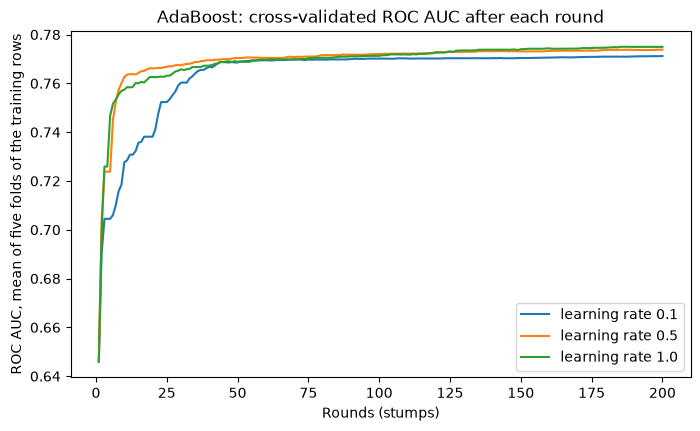

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
for rate in learning_rates:
    ax.plot(np.arange(1, 201), curves[rate], label=f"learning rate {rate}")
ax.set_title("AdaBoost: cross-validated ROC AUC after each round")
ax.set_xlabel("Rounds (stumps)")
ax.set_ylabel("ROC AUC, mean of five folds of the training rows")
ax.legend()
plt.show()

* The curves rise steeply, then flatten. A smaller learning rate is the same climb, stretched over more rounds.

## 6.7 A Weighted Vote, Not a Frequency

AdaBoost's model is a vote. Each stump says +1 (default) or -1 (no default), and its say counts in proportion to its stump weight. Divide the weighted sum of the says by the sum of the weights and you get the **weighted vote**, between -1 (every stump says no default) and +1 (every stump says default).

Q. Compute the weighted vote by hand on the validation rows. How do scikit-learn's `decision_function` and `predict_proba` relate to it, and how does the output's average compare with the default rate?

In [24]:
# each stump's say on every validation account: +1 for default, -1 for no default
# (the stumps inside AdaBoost were fitted on a plain array of the columns, so they are given one)
says = np.column_stack([2 * s.predict(X_valid.to_numpy()) - 1 for s in ada.estimators_])
# the weighted vote: the says times the stump weights, divided by the sum of the weights
vote = says @ ada.estimator_weights_ / ada.estimator_weights_.sum()
print(f"weighted vote from {vote.min():.4f} to {vote.max():.4f}")
print(f"decision_function equals 2 x vote within 1e-12: {np.abs(ada.decision_function(X_valid) - 2 * vote).max() < 1e-12}")
print(f"predict_proba equals 1 / (1 + e^(-2 x vote)) within 1e-12: {np.abs(score_valid - 1 / (1 + np.exp(-2 * vote))).max() < 1e-12}")
print(f"possible range of the output: {1 / (1 + np.exp(2)):.4f} to {1 / (1 + np.exp(-2)):.4f}")
print(f"output on the validation rows: {score_valid.min():.4f} to {score_valid.max():.4f}, mean {score_valid.mean():.4f}")
print(f"validation default rate: {y_valid.mean():.4f}")

weighted vote from -0.4803 to 0.3243


decision_function equals 2 x vote within 1e-12: True
predict_proba equals 1 / (1 + e^(-2 x vote)) within 1e-12: True
possible range of the output: 0.1192 to 0.8808
output on the validation rows: 0.2768 to 0.6567, mean 0.4051
validation default rate: 0.2212


* The weighted vote runs from -0.4803 to 0.3243. scikit-learn's `decision_function` is twice the vote, and for two classes `predict_proba` is 1 / (1 + e^(-2 x vote)), both exactly. Because the vote can never leave -1 to +1, the output can never go below 0.1192 or above 0.8808, whatever the account.
* Its average, 0.4051, is far above the validation default rate of 0.2212. The output ranks the accounts well, but its level is not a share of defaults. It is the model's score, never called a probability.

Q. Sort the validation accounts into ten equal groups by score. In each group, compare the mean score with the share that defaulted.

             accounts  mean score  default rate
score group                                    
1                 600      0.3244        0.0583
2                 600      0.3510        0.0683
3                 600      0.3637        0.0900
4                 600      0.3754        0.1283
5                 604      0.3832        0.1308
6                 597      0.3920        0.1692
7                 600      0.4068        0.1950
8                 599      0.4278        0.2604
9                 600      0.4650        0.4217
10                600      0.5623        0.6900


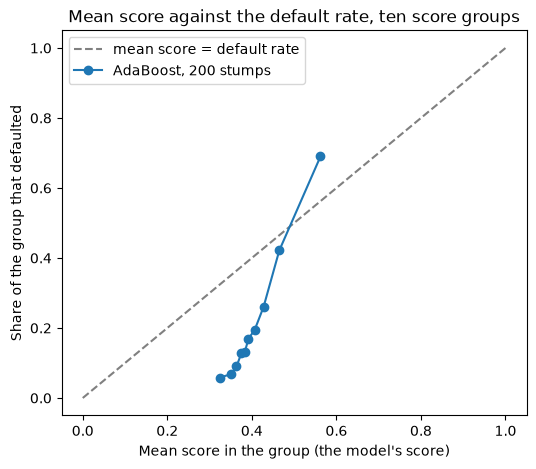

In [25]:
# ten groups of about 600 accounts each, from the lowest scores to the highest
group = pd.qcut(score_valid, 10, labels=range(1, 11))
calibration = pd.DataFrame({"accounts": pd.Series(score_valid).groupby(group, observed=True).size(),
                            "mean score": pd.Series(score_valid).groupby(group, observed=True).mean(),
                            "default rate": pd.Series(y_valid.to_numpy()).groupby(group, observed=True).mean()})
calibration.index.name = "score group"
print(calibration.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="mean score = default rate")
ax.plot(calibration["mean score"], calibration["default rate"], marker="o", label="AdaBoost, 200 stumps")
ax.set_title("Mean score against the default rate, ten score groups")
ax.set_xlabel("Mean score in the group (the model's score)")
ax.set_ylabel("Share of the group that defaulted")
ax.legend()
plt.show()

* The default rate climbs from 5.8 percent in the lowest group to 69.0 percent in the highest, so the ranking is real. But the mean scores run only from 0.3244 to 0.5623: squeezed toward the middle: above the default rate in the low groups, below it in the highest, and the line is much steeper than the diagonal.
* That is why the output is called the model's score: it ranks, and its level means nothing on its own. A threshold for it must come from the model's own scores (day 5's out-of-fold rule, used in the Git section), never from 0.5. Day 13 shows how to turn a score like this back into a probability.

## 6.8 The Rows That Carry the Weight

After many rounds, the weights show which rows the stumps keep getting wrong. They describe the model's struggle with these rows; they say nothing about the accounts beyond this file.

Q. Run 50 rounds by hand and keep the row weights. Which rows carry the most weight?

In [26]:
hand_50, weights_50 = boost_rounds(50)
# the first 50 stump weights of the 200-stump model are the hand loop's
print(f"50 hand weights equal ada.estimator_weights_[:50] within 1e-12: "
      f"{np.abs(hand_50['stump weight'] - ada.estimator_weights_[:50]).max() < 1e-12}")

# each row's weight as a multiple of its starting weight, 1/n
relative = weights_50 * n_rows
print(f"weights after 50 rounds: {relative.min():.2f} to {relative.max():.2f} times the starting weight")

heavy = []
for k in [1, 2, 3, 4]:
    rows_k = relative >= k
    heavy.append({"weight at least": f"{k} x start", "rows": int(rows_k.sum()),
                  "share of weight": weights_50[rows_k].sum(), "default rate": y_train[rows_k].mean(),
                  "share with PAY_0 >= 2": (X_train.loc[rows_k, "PAY_0"] >= 2).mean(),
                  "median LIMIT_BAL": X_train.loc[rows_k, "LIMIT_BAL"].median()})
heavy.append({"weight at least": "all rows", "rows": n_rows, "share of weight": 1.0, "default rate": y_train.mean(),
              "share with PAY_0 >= 2": (X_train["PAY_0"] >= 2).mean(), "median LIMIT_BAL": X_train["LIMIT_BAL"].median()})
print(pd.DataFrame(heavy).set_index("weight at least").round(4).to_string())

50 hand weights equal ada.estimator_weights_[:50] within 1e-12: True
weights after 50 rounds: 0.29 to 6.63 times the starting weight
                  rows  share of weight  default rate  share with PAY_0 >= 2  median LIMIT_BAL
weight at least                                                                               
1 x start         3975           0.5637        0.7565                 0.2284           90000.0
2 x start         2617           0.4578        0.8666                 0.1334          110000.0
3 x start         1309           0.2782        0.9343                 0.0657          140000.0
4 x start          387           0.0982        0.9535                 0.0465          210000.0
all rows         18000           1.0000        0.2212                 0.1047          140000.0


* After 50 rounds, weights run from 0.29 to 6.63 times where they started.
* The 1,309 rows at three times their starting weight or more are 7.3 percent of the rows and carry 27.8 percent of the weight. Of them, 93.4 percent defaulted, against 22.1 percent of all rows, and only 6.6 percent showed a delay of two months or more in `PAY_0`, against 10.5 percent of all rows.
* So the heaviest rows are mostly accounts that defaulted although their latest repayment status looked current. The early stumps' questions put them on the "no default" side, and every round that misses them again raises their weight again. That is a description of where the model struggles in this file, not a judgment of these accounts, and the same mechanism would raise the weight of a row whose outcome no question in these 19 columns can separate.

> **STORY: where the week's name comes from.** In August 1997 Yoav Freund and Robert E. Schapire published a paper titled "A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting" in the *Journal of Computer and System Sciences* (volume 55, issue 1, pages 119 to 139). The last word of its title is the name of this week: boosting, fitting models one after another so that each one works on what the last got wrong.
>
> Source (read 2026-10-05): the Crossref record of the paper, https://api.crossref.org/works/10.1006/jcss.1997.1504, DOI https://doi.org/10.1006/jcss.1997.1504. Only the title, authors, journal, volume, issue, pages, and date are taken from it; the paper itself was not read for this course.

## Excel Side by Side

Excel has no AdaBoost: no worksheet function fits a stump or a sequence of them. What Excel can do is the arithmetic of every round once the stumps are chosen: the weighted error, the stump's weight, and the new row weights. Here the three stumps of section 6.4 were fitted in Python, and only their "missed" columns (1 where the stump is wrong, 0 where it is right) were pasted into A2:C18001; every number after that is Excel's. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Starting weights, D2 down | `np.full(n_rows, 1 / n_rows)` | `=1/ROWS($A$2:$A$18001)` | 1/18,000 in every row |
| Round 1 weighted error, M2 | `np.sum(weights * missed) / np.sum(weights)` | `=SUMPRODUCT(D2:D18001,A2:A18001)/SUM(D2:D18001)` | 0.1791 |
| Round 1 stump weight, M3 | `ensemblekit.samme_alpha(e)` | `=LN((1-M2)/M2)` | 1.5228 |
| Missed rows grow, E2 down | `weights * np.exp(alpha * missed)` | `=D2*EXP($M$3*A2)` | |
| New weights, F2 down | `/ new.sum()` in `reweight` | `=E2/SUM($E$2:$E$18001)` | sum to 1 |
| Missed rows' share after | `new_weights[missed == 1].sum()` | `=SUMPRODUCT(F2:F18001,A2:A18001)` | 0.5000 |
| Largest weight over smallest | `new_weights.max() / new_weights.min()` | `=MAX(F2:F18001)/MIN(F2:F18001)` | 4.5849 |
| Rounds 2 and 3 | `boost_rounds(3)` | the same formulas on columns F and H with B and C | weights 0.3526 and 0.2592 |

**Round one.** With the weights in D and the first stump's misses in A, `SUMPRODUCT(D2:D18001,A2:A18001)` adds the weight of the missed rows and dividing by `SUM(D2:D18001)` makes it a share: that is the weighted error. `LN((1-M2)/M2)` is the stump's weight. In E2, `=D2*EXP($M$3*A2)` filled down multiplies a missed row by e^alpha and leaves a correct row alone (EXP(0) is 1); in F2, `=E2/SUM($E$2:$E$18001)` filled down divides by the total. The `$` signs keep the weight cell and the total fixed as the formula fills down.

**Rounds two and three** repeat the same five formulas, each on the weights the round before produced. Excel's three stump weights are scikit-learn's `estimator_weights_`.

**`LOG` is not `LN`.** Excel's `LOG` with one argument is base 10: tested, `=LOG(4)` returned 0.6021 and `=LN(4)` returned 1.3863. The stump's weight uses `LN`; `=LOG((1-M2)/M2)` gives 0.6613, the wrong number the AI check in the exercises produces.

Q. Do Excel's numbers equal Python's?

In [27]:
# Excel's numbers, from the course's Excel check, beside the hand loop and scikit-learn
excel_weights = [1.5227593150883587, 0.3525669050315666, 0.2592139184745186]
excel_errors = [0.17905555555553163, 0.412760092009041, 0.4355569542562329]
side_by_side = pd.DataFrame({"Excel error": excel_errors, "Python error": hand_3["weighted error"].to_numpy(),
                             "Excel weight": excel_weights, "scikit-learn weight": ada_3.estimator_weights_},
                            index=hand_3.index)
side_by_side["within 1e-12"] = ((side_by_side["Excel error"] - side_by_side["Python error"]).abs() < 1e-12) & \
                               ((side_by_side["Excel weight"] - side_by_side["scikit-learn weight"]).abs() < 1e-12)
print(side_by_side.round(4).to_string())
print(f"missed rows' share of the weight after each round in Excel: {[round(s, 4) for s in [0.5000000000001712, 0.5000000000000003, 0.5000000000000598]]}")

       Excel error  Python error  Excel weight  scikit-learn weight  within 1e-12
round                                                                            
1           0.1791        0.1791        1.5228               1.5228          True
2           0.4128        0.4128        0.3526               0.3526          True
3           0.4356        0.4356        0.2592               0.2592          True
missed rows' share of the weight after each round in Excel: [0.5, 0.5, 0.5]


* All three rounds match within 1e-12. The digits past the twelfth differ, because Excel and numpy add 18,000 products in a different order, so the comparison is printed as "within 1e-12", never as the gap.
* After every round, the missed rows carry half the weight in Excel too.

## Save the Day with Git

The work folder is new today, so it gets its own repository. The first commit holds Course 4's `mlkit.py` and the two module files as they stand after today's functions. Today's Git step is `git stash`: try an experiment on a tracked file, put it aside without committing, compare, and throw it away.

Q. Make the work folder a repository.

In [28]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [29]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_06_ubg4tldf and nowhere else


Q. Tell Git which files never to track, and commit the code.

In [30]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [31]:
# the data files are copies of the course's data and stay untracked
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "ensemblekit through day 6: samme_alpha and reweight for AdaBoost by hand, 25 tests"
!git -C "{work}" log --oneline

ecad67c ensemblekit through day 6: samme_alpha and reweight for AdaBoost by hand, 25 tests


Q. Write today's model to the experiment log, at the threshold from out-of-fold scores on the training rows.

In [32]:
# day 5's rule: the threshold for recall 0.70 comes from out-of-fold scores on the training rows
threshold, oof_score = ensemblekit.oof_threshold(
    AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=200, random_state=SEED),
    X_train, y_train)


def log_row(name, model_score, model_threshold):
    """One row of the experiment log: validation metrics, with flags at the model's own threshold."""
    metrics = mlkit.classification_metrics(y_valid, (model_score >= model_threshold).astype(int))
    return {"model": name, "rows": "validation", "roc_auc": roc_auc_score(y_valid, model_score),
            "average_precision": average_precision_score(y_valid, model_score), "threshold": model_threshold, **metrics}


results = pd.DataFrame([log_row("adaboost_200_stumps", score_valid, threshold)])
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))
print(f"accuracy of flagging no account (all-zero baseline) on the validation rows: {1 - y_valid.mean():.4f}")

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
adaboost_200_stumps,validation,0.7708,0.5321,0.4009,0.7047,0.4021,0.6888,0.5078

accuracy of flagging no account (all-zero baseline) on the validation rows: 0.7788


* The out-of-fold threshold is 0.4009, a score, chosen on the training rows by Course 4's recall rule. A flag at 0.5 has no special meaning for a score whose level is not a share of defaults. At it, the model flags accounts with validation recall 0.6888 and precision 0.4021. Accuracy (0.7047) sits beside the all-zero baseline (0.7788) and chooses nothing.

In [33]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: AdaBoost, 200 stumps, validation metrics at the out-of-fold threshold"
!git -C "{work}" log --oneline

36252a8 Experiment log: AdaBoost, 200 stumps, validation metrics at the out-of-fold threshold
ecad67c ensemblekit through day 6: samme_alpha and reweight for AdaBoost by hand, 25 tests


Q. Try an experiment without committing it: AdaBoost at learning rate 0.5, added to `results.csv`. What does `git diff` show?

In [34]:
# the experiment: the same model at learning rate 0.5, with its own out-of-fold threshold
ada_05 = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=200,
                            learning_rate=0.5, random_state=SEED).fit(X_train, y_train)
threshold_05, _ = ensemblekit.oof_threshold(
    AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=200, learning_rate=0.5,
                       random_state=SEED), X_train, y_train)
experiment = pd.concat([results, pd.DataFrame([log_row("adaboost_200_stumps_rate_0.5", ada_05.predict_proba(X_valid)[:, 1],
                                                        threshold_05)])])
experiment.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")

In [35]:
# compare the experiment with the last commit
!git -C "{work}" diff results.csv

diff --git a/results.csv b/results.csv
index ab42ed7..8b466d2 100644
--- a/results.csv
+++ b/results.csv
@@ -1,2 +1,3 @@
 model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
 adaboost_200_stumps,validation,0.7708,0.5321,0.4009,0.7047,0.4021,0.6888,0.5078
+adaboost_200_stumps_rate_0.5,validation,0.7706,0.5327,0.3164,0.6980,0.3955,0.6918,0.5033


* One added line: validation ROC AUC 0.7706 at rate 0.5 against 0.7708 at rate 1.0. Section 6.6 found the same, inside the training rows: after 200 rounds the two rates end up close.

Q. Put the experiment aside with `git stash`, look at what was saved, and confirm the file is back to its last commit.

In [36]:
# stash saves the change and puts results.csv back as it was committed
!git -C "{work}" stash push -q -m "experiment: AdaBoost at learning rate 0.5"
!git -C "{work}" stash list
!git -C "{work}" status --short

stash@{0}: On main: experiment: AdaBoost at learning rate 0.5


?? benchmark.csv


?? credit_card_default.csv
?? ratings.csv


In [37]:
# results.csv is the committed version again: one model
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
adaboost_200_stumps,validation,0.7708,0.5321,0.4009,0.7047,0.4021,0.6888,0.5078



* `git stash` saved the change under its message and restored the committed file; `status --short` lists only the untracked data files and nothing modified. The experiment is not lost: `git stash pop` would bring it back.

Q. The experiment changes nothing worth keeping. Drop it.

In [38]:
# show the stashed change one last time, then drop it; the history is unchanged
!git -C "{work}" stash show -p
!git -C "{work}" stash drop -q
!git -C "{work}" stash list
!git -C "{work}" log --oneline

diff --git a/results.csv b/results.csv
index ab42ed7..8b466d2 100644
--- a/results.csv
+++ b/results.csv
@@ -1,2 +1,3 @@
 model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
 adaboost_200_stumps,validation,0.7708,0.5321,0.4009,0.7047,0.4021,0.6888,0.5078
+adaboost_200_stumps_rate_0.5,validation,0.7706,0.5327,0.3164,0.6980,0.3955,0.6918,0.5033


36252a8 Experiment log: AdaBoost, 200 stumps, validation metrics at the out-of-fold threshold
ecad67c ensemblekit through day 6: samme_alpha and reweight for AdaBoost by hand, 25 tests


* After `stash drop` the list is empty and the log still holds two commits. Use a stash for a quick "what if" on a tracked file; commit anything you want to keep.

## Bring It Home

Add today's functions to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code ensemblekit.py
code test_ensemblekit.py
```

**Step 2.** Paste the code of today's two `%%writefile -a ensemblekit.py` cells (sections 6.3), without their first lines, at the end of `ensemblekit.py`; do the same for the three `%%writefile -a test_ensemblekit.py` cells (sections 6.3 and 6.4). Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_ensemblekit.py
```

The last line says `25 passed`.

**Step 4.** Look at the change, then commit the code only.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "ensemblekit through day 6: samme_alpha and reweight for AdaBoost by hand, 25 tests"
```

**Step 5.** Practise a stash on your own log: change a line of a tracked file, then put the change aside and drop it.

```powershell
git stash push -m "trying something"
git stash list
git stash drop
```

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say how boosting differs from bagging: trees one after another on reweighted rows, combined by a weighted vote.
* Run an AdaBoost round by hand: weighted error, `samme_alpha`, `reweight`, and say why the missed rows end up with half the weight.
* Match `AdaBoostClassifier`'s `estimator_weights_` with a loop of your own.
* Compare learning rates and numbers of rounds by cross-validation inside the training rows, never on the validation rows.
* Say why AdaBoost's output is the model's score and not a probability, and show it with a calibration chart.
* Describe the rows a boosted model keeps getting wrong, without judging them.
* Put an experiment aside with `git stash` and drop it.

Tomorrow, day 7: gradient boosting, built from residuals on the benchmark bonds.

## Exercises

The exercises use Course 4's card rows: fitted on the 18,000 training rows, scored on the 6,000 validation rows or by cross-validation inside the training rows, the test rows closed. The four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card rows, fits section 6.2's stump and a one-round AdaBoost, measures round one's weighted error, and defines `check`, a small function that marks your answers.

In [39]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier

# Course 4's training and validation rows of the card file
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
n_rows = len(X_train)

# section 6.2's stump, its missed rows, and round one's weighted error with equal weights
stump = DecisionTreeClassifier(max_depth=1, random_state=SEED).fit(X_train, y_train)
missed_1 = (stump.predict(X_train) != y_train.to_numpy()).astype(float)
error_1 = float(missed_1.mean())
# a one-round AdaBoost, for scikit-learn's first stump weight
ada_1 = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1, random_state=SEED), n_estimators=1,
                           random_state=SEED).fit(X_train, y_train)
print(f"round one's weighted error: {error_1:.4f}")


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

round one's weighted error: 0.1791


### Exercise 1

Q. Fit AdaBoost with 200 trees of depth 2 (`DecisionTreeClassifier(max_depth=2, random_state=SEED)`, `n_estimators=200`, `random_state=SEED`) on the training rows. Store its validation ROC AUC in **ex1_auc**.

In [40]:
ex1_auc = ...

In [41]:
check("Exercise 1 the depth-2 model's validation ROC AUC", ex1_auc, 0.7730685554156693)

Exercise 1 the depth-2 model's validation ROC AUC: not attempted yet


### Exercise 2

Q. Recompute section 6.6's cross-validated curve for learning rate 1.0 only (five folds from `mlkit.cv_folds()`, 200 stumps, `staged_decision_function`, the mean over folds). Store in **ex2_round** the first round whose cross-validated ROC AUC is within 0.001 of the curve's highest value.

In [42]:
ex2_round = ...

In [43]:
check("Exercise 2 the round within 0.001 of the best", ex2_round, 150)

Exercise 2 the round within 0.001 of the best: not attempted yet


### Exercise 3

Q. Add a function to your module. `weighted_error(weights, missed)` returns the share of the total row weight on the missed rows. Write the docstring first, and make it raise `ValueError` on lengths that differ, an empty input, a negative weight, or weights that sum to 0. Then add `test_weighted_error_hand`, with a hand case where the weights sum to 1, one where they do not, and lengths that differ. Run pytest, reload the module, and store `ensemblekit.weighted_error(np.full(n_rows, 1 / n_rows), missed_1)` in **ex3_error**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [44]:
%%writefile -a ensemblekit.py


# Exercise 3: write weighted_error(weights, missed) below this line

Appending to ensemblekit.py


In [45]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_weighted_error_hand() below this line

Appending to test_ensemblekit.py


In [46]:
# run pytest, reload the module, then call your function
ex3_error = ...

In [47]:
check("Exercise 3 weighted_error on round one", ex3_error, 0.17905555555555558)

Exercise 3 weighted_error on round one: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for the function that gives a stump its weight, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The weight AdaBoost gives one stump's vote, from the stump's weighted error.

    weighted_error is the share of the row weight on the rows the stump got wrong, above 0 and below 0.5.
    Returns ln((1 - e) / e) in natural logs, as AdaBoostClassifier's estimator_weights_ with two classes.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a positive number for any error below 0.5, and contains one bug.

In [48]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def stump_weight(weighted_error):
    """The weight AdaBoost gives one stump's vote, from the stump's weighted error.

    weighted_error is the share of the row weight on the rows the stump got wrong, above 0 and below 0.5.
    Returns ln((1 - e) / e) in natural logs, as AdaBoostClassifier's estimator_weights_ with two classes.
    """
    # the log-odds of the stump being right
    return np.log10((1 - weighted_error) / weighted_error)

Q. Before you run the next cell: what weight will `stump_weight` give round one's stump, whose weighted error is 0.1791? Section 6.3 found 1.5228.

In [49]:
print(f"stump_weight({error_1:.4f}) = {stump_weight(error_1):.4f}")
print(f"a stump right on 80 percent of the weight: {stump_weight(0.2):.4f}")

stump_weight(0.1791) = 0.6613
a stump right on 80 percent of the weight: 0.6021


Q. Test the function against its docstring before you trust it.

In [50]:
# the test, written from the docstring before the code is trusted
ai_weight = stump_weight(error_1)
# 1. the natural log of the odds, the module's samme_alpha
assert abs(ai_weight - ensemblekit.samme_alpha(error_1)) < 1e-12, "stump_weight is not samme_alpha: check the log's base"
# 2. scikit-learn's first stump weight on the same rows
assert abs(ai_weight - ada_1.estimator_weights_[0]) < 1e-12, "stump_weight is not estimator_weights_"
print(f"stump_weight({error_1:.4f}) = {ai_weight:.4f}, equal to samme_alpha and estimator_weights_")

AssertionError: stump_weight is not samme_alpha: check the log's base

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store `stump_weight(error_1)` in **ex4_weight**.

In [51]:
# fix the function above and run the test again, then store the answer
ex4_weight = ...

In [52]:
check("Exercise 4 the fixed stump weight", ex4_weight, 1.522759315088196)

Exercise 4 the fixed stump weight: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```